# TASK 4.1

In [5]:
!pip install torch torchvision

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/113.8 MB 4.0 MB/s eta 0:00:29
   ---------------------------------------- 1.3/113.8 MB 3.0 MB/s eta 0:00:39
    --------------------------------------- 1.8/113.8 MB 2.9 MB/s eta 0:00:38
    --------------------------------------- 2.4/113.8 MB 2.9 MB/s eta 0:00:39
   - -------------------------------------- 2.9/113.8 MB 2.8 MB/s eta 0:00:41
   - -------------------------------------- 3.4/113.8 MB 2.8 MB/s eta 0:00:40
   - -------------------------------------- 3.9/113.8 MB 2.7 MB/s eta 0:00:42
   - -------------------------------------- 4.2/113.8 MB 2.6 MB/s eta 0:00:42
   - -------------------------------------- 4.7/113.8 MB 2.5 MB/s eta 0:00:44
   - -------------------------------------- 5.2/113.8 MB 2.5 MB/s eta 0:00:44
   -- ------------------------------------- 5.8/113.8 MB 2.4 MB/s eta 0:00:45
   -- ------------------------------------- 6.3/113.8 MB 2.5 MB/s eta 0


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import torch
print(torch.__version__)


2.10.0+cpu


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Imported successfully !!")

Imported successfully !!


What problem does CNN solve that MLP couldn’t?

In MLP:
4096 pixels → fully connected

Problem:   
Loses spatial relationships ,
Too many parameters , 
Doesn’t detect local patterns efficiently

CNN introduces:

1️⃣ Convolution layers :  
Small filters (3×3, 5×5) , 
Slide over image , 
Detect local patterns (edges, curves)

2️⃣ Weight sharing  :  
Same filter applied everywhere , 
Fewer parameters , 
More generalizable
 
3️⃣ Pooling : 
Reduces spatial size , 
Keeps important features , 
Makes model robust

**Task Goal**

Build a CNN that:

Classifies 5 dino classes

No pretrained model

Shows:   
Confusion matrix  ,  
Loss graph   , 
Accuracy graph , 
Some prediction visuals

## STEP 1 — Extract & Inspect Dataset (PyTorch Pipeline Begins)

### STEP 1.1 — Unzip dataset

In [9]:
import zipfile
import os

with zipfile.ZipFile("A,B,CNNS_with_Tim.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

### STEP 1.2 — Inspect Structure

In [10]:
print(os.listdir("dataset"))

['A,B,CNNS_with_Tim']


In [11]:
print(os.listdir("dataset/A,B,CNNS_with_Tim"))

['taskDesc.txt', 'veggie_heap_testing', 'veggie_heap_training']


## STEP 2 — Load Training Dataset (PyTorch ImageFolder)

### Step 2.1 — Define Transform

In [13]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

Step 5.2 — Load Training Data

In [14]:
from torchvision import datasets

train_path = "dataset/A,B,CNNS_with_Tim/veggie_heap_training"

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)

In [17]:
print("Classes:", train_dataset.classes)
print()
print("Class to index:", train_dataset.class_to_idx)
print()
print("Total training images:", len(train_dataset))

Classes: ["Apatosaur Aphie's Apples", "Bluplocephalus Bob's Blueberries", "Cherizinoasaur Cher's Cherries", "Corythosaurus Cory's Corn", "Grapthorina Greta's Grapes", "Pachycephalosaurus Perry's Peaches", "Pepteranodon Pep's Peppers", "Potoceratops Pott's Potatoes", "Rhaspdodon Ribery's Raspberries", "Stribecosaurus Stan's Strawberries", "Thyreosaur Tim's Thyme", 'vacation_photos']

Class to index: {"Apatosaur Aphie's Apples": 0, "Bluplocephalus Bob's Blueberries": 1, "Cherizinoasaur Cher's Cherries": 2, "Corythosaurus Cory's Corn": 3, "Grapthorina Greta's Grapes": 4, "Pachycephalosaurus Perry's Peaches": 5, "Pepteranodon Pep's Peppers": 6, "Potoceratops Pott's Potatoes": 7, "Rhaspdodon Ribery's Raspberries": 8, "Stribecosaurus Stan's Strawberries": 9, "Thyreosaur Tim's Thyme": 10, 'vacation_photos': 11}

Total training images: 9835


## STEP 3 — Clean the Dataset (Remove “vacation_photos”)

### STEP 3.1 

In [18]:
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)

In [19]:
vacation_index = train_dataset.class_to_idx['vacation_photos']
print("Vacation class index:", vacation_index)

Vacation class index: 11


In [20]:
from torch.utils.data import Subset

filtered_indices = [
    i for i, (_, label) in enumerate(train_dataset.samples)
    if label != vacation_index
]

filtered_dataset = Subset(train_dataset, filtered_indices)

In [21]:
print("Total filtered images:", len(filtered_dataset))

Total filtered images: 8905


In [22]:
num_classes = len(train_dataset.classes) - 1

## STEP 4 — Create DataLoader (Filtered Dataset)

In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    filtered_dataset,
    batch_size=32,
    shuffle=True
)

STEP 7.1 — Verify Batch Shape

In [24]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Sample labels:", labels[:10])

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])
Sample labels: tensor([ 6,  5, 10,  3,  1,  2,  3,  4, 10,  0])


## STEP 5 — Define CNN Architecture

Input (3×64×64)

Conv(3 → 16) + ReLU
MaxPool

Conv(16 → 32) + ReLU
MaxPool

Conv(32 → 64) + ReLU
MaxPool

Flatten

Fully Connected
Fully Connected (Output 11 classes)

### Step 8.1 — Define CNN Class

In [25]:
import torch.nn as nn
import torch.nn.functional as F

class DinoCNN(nn.Module):
    def __init__(self, num_classes=11):
        super(DinoCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 → 16
        x = self.pool(F.relu(self.conv3(x)))   # 16 → 8

        x = x.view(x.size(0), -1)              # flatten

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### Step 8.2 — Instantiate Model

In [26]:
model = DinoCNN(num_classes=11)
print(model)

DinoCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=11, bias=True)
)


## STEP 6 — Define Loss Function & Optimizer

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## STEP 7 — Training Loop

### STEP 10.1 — Move model to device

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cpu


### STEP 10.2 — Training Code

In [29]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/10] Loss: 1.0893 Accuracy: 63.04%
Epoch [2/10] Loss: 0.4056 Accuracy: 86.23%
Epoch [3/10] Loss: 0.2605 Accuracy: 91.25%
Epoch [4/10] Loss: 0.1976 Accuracy: 93.32%
Epoch [5/10] Loss: 0.1690 Accuracy: 94.05%
Epoch [6/10] Loss: 0.1158 Accuracy: 95.98%
Epoch [7/10] Loss: 0.1169 Accuracy: 96.09%
Epoch [8/10] Loss: 0.0948 Accuracy: 96.78%
Epoch [9/10] Loss: 0.0700 Accuracy: 97.51%
Epoch [10/10] Loss: 0.0520 Accuracy: 98.10%


## STEP 11 — Plot Graphs (Timothy wants visuals)

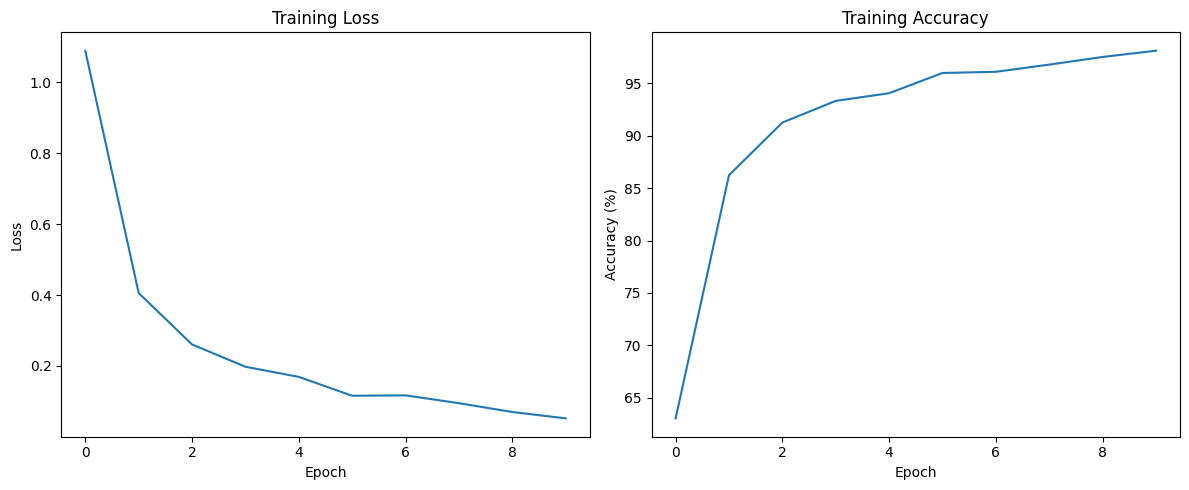

In [30]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

## STEP 12 — Create Validation Set

In [31]:
from torch.utils.data import random_split

train_size = int(0.8 * len(filtered_dataset))
val_size = len(filtered_dataset) - train_size

train_subset, val_subset = random_split(filtered_dataset, [train_size, val_size])

In [32]:
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

## STEP 13 — Evaluate on Validation Set

In [33]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [34]:
import numpy as np

val_accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 98.03%


## STEP 14 — Confusion Matrix

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [36]:
cm = confusion_matrix(all_labels, all_preds)

In [37]:
class_names = [c for c in train_dataset.classes if c != 'vacation_photos']

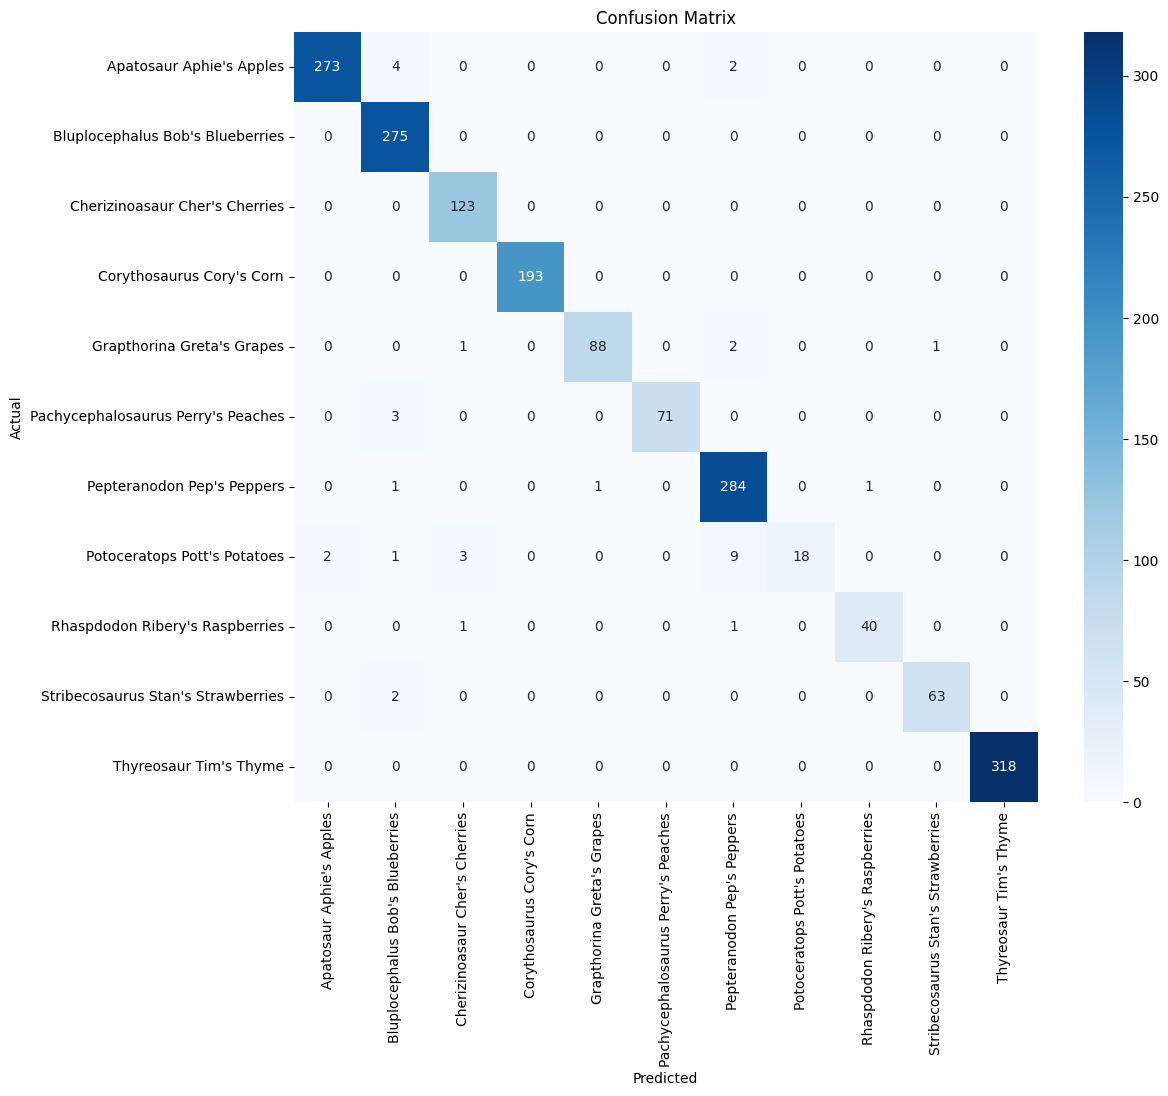

In [38]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()